In [43]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: Ashlesha Tayade
- PRN : 260240128008
-----------------------------------------
- Name: Ruchika Gaikwad
- PRN : 20240128036

# Image Processing with Neural Network

## Assignment A05 :
## Working with PyTorch
- Custom DataSet with common transformation
- Activation function of your choice
- Regularization:
    - L2,
    - BatchNorm,
    - Dropout,
    - Early Stopping.

- multi-class output
- Fashion MNIST dataset

In [44]:
###-----------------
### Import Libraries
###-----------------

import os
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix

In [45]:
###----------------------
### Some basic parameters
###----------------------

inpDir   = '../../input'
outDir   = '../output'
modelDir = '../models'
subDir   = 'fashion_mnist'
altName  = 'A05_fashion_cnn'

RANDOM_STATE = 24
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

EPOCHS      = 60
BATCH_SIZE  = 64
ALPHA       = 0.0005     # lower LR — reduces val fluctuation
WEIGHT_DECAY = 1e-4      # L2 regularization
PATIENCE    = 15
LR_PATIENCE = 5
LR_FACTOR   = 0.3
MIN_LR      = 1e-7

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large',
          'ytick.labelsize': 'x-large'}

CMAP = plt.cm.coolwarm
plt.rcParams.update(params)

In [46]:
os.makedirs(os.path.join(modelDir, subDir), exist_ok=True)

## All about CUDA

In [47]:
print('Is CUDA available: ', torch.cuda.is_available())
print('CUDA version:      ', torch.version.cuda)

if torch.cuda.is_available():
    print('Current Device ID: ', torch.cuda.current_device())
    print('Device Name:       ', torch.cuda.get_device_name(torch.cuda.current_device()))

Is CUDA available:  True
CUDA version:       12.8
Current Device ID:  0
Device Name:        Tesla T4


In [48]:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed=RANDOM_STATE)
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Using {device} device')

Using cuda device


## Load Fashion MNIST Dataset

In [49]:
class_names = {0: 'T-shirt/top', 1: 'Trouser',  2: 'Pullover', 3: 'Dress', 4: 'Coat',
               5: 'Sandal',      6: 'Shirt',     7: 'Sneaker',  8: 'Bag',   9: 'Ankle boot'}

In [50]:
local_path = r'D:\Deep_Learning\SharedData\fashion-mnist_train.csv'

if os.path.exists(local_path):
    # ── Local VS Code ──
    inpDir_data = r'D:\Deep_Learning\SharedData'
    train_df = pd.read_csv(os.path.join(inpDir_data, 'fashion-mnist_train.csv'), header=0)
    test_df  = pd.read_csv(os.path.join(inpDir_data, 'fashion-mnist_test.csv'),  header=0)

else:
    # ── Google Colab — load from Keras ──
    import tensorflow as tf
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

    # Name pixel columns as strings to avoid dict sorting conflict
    pixel_cols = [f'p{i}' for i in range(784)]

    train_df = pd.DataFrame(X_train.reshape(-1, 784), columns=pixel_cols)
    train_df.insert(0, 'label', y_train)

    test_df = pd.DataFrame(X_test.reshape(-1, 784), columns=pixel_cols)
    test_df.insert(0, 'label', y_test)

print('Train shape:', train_df.shape)   # (60000, 785)
print('Test shape :', test_df.shape)    # (10000, 785)

Train shape: (60000, 785)
Test shape : (10000, 785)


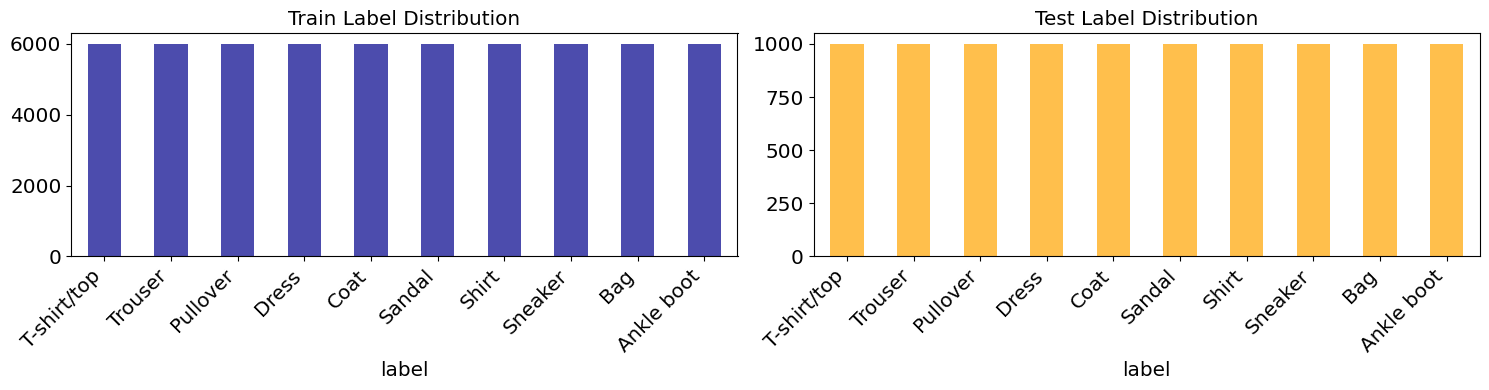

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

train_df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], title='Train Label Distribution',
    color='DarkBlue', alpha=0.7)
axes[0].set_xticklabels([class_names[i] for i in range(10)], rotation=45, ha='right')

test_df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], title='Test Label Distribution',
    color='Orange', alpha=0.7)
axes[1].set_xticklabels([class_names[i] for i in range(10)], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Custom Dataset

In [52]:
class FashionMNISTDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        super(FashionMNISTDataset, self).__init__()

        labels  = dataframe.iloc[:, 0].to_numpy().astype(np.int64)
        images  = dataframe.iloc[:, 1:].to_numpy().astype(np.float32)

        # ── Pre-convert to tensors ONCE (big speed boost) ──
        images  = images.reshape(-1, 1, 28, 28) / 255.0          # normalize here
        self.images    = torch.tensor(images,  dtype=torch.float32)
        self.labels    = torch.tensor(labels,  dtype=torch.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = self.images[index]    # already a tensor, no conversion needed
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [53]:
# ── Augmentation for train (active only during training) ──
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))   # randomly erase small patches
])

# ── Test: no augmentation ──
test_transform = None

In [54]:
train_dataset = FashionMNISTDataset(train_df, transform=train_transform)
test_dataset  = FashionMNISTDataset(test_df,  transform=test_transform)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples : {len(test_dataset)}')

Train samples: 60000
Test samples : 10000


In [55]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')

Train batches: 938, Test batches: 157


In [56]:
def show_samples(data_loader, class_labels, num_samples=BATCH_SIZE):
    images, labels = next(iter(data_loader))

    cols = 8
    rows = num_samples // 8

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 2))
    axes = axes.ravel()

    for i in range(num_samples):
        img = images[i].squeeze().numpy()
        axes[i].imshow(img, cmap=plt.cm.binary)
        axes[i].set_title(class_labels[labels[i].item()], fontsize=7)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

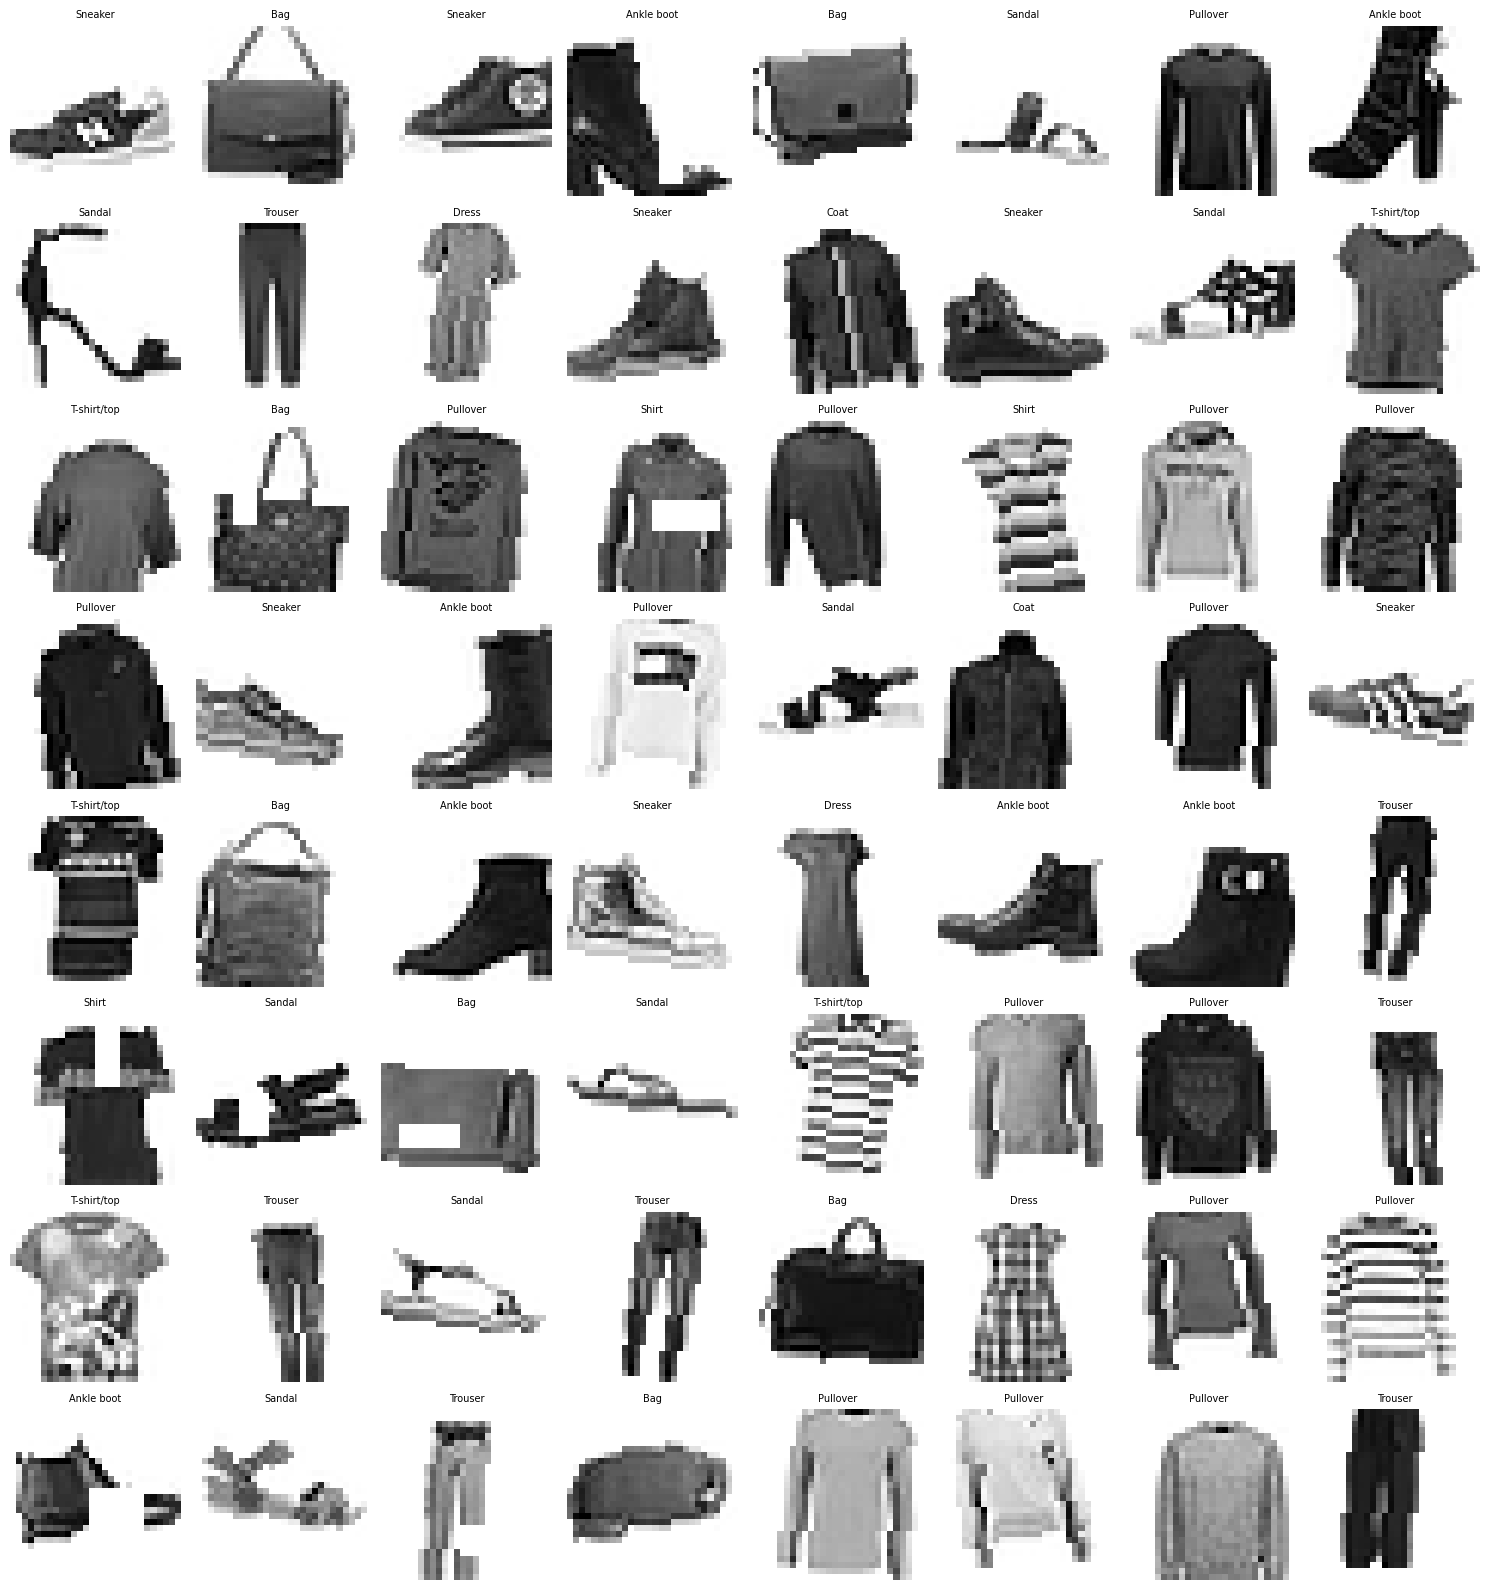

In [57]:
show_samples(train_loader, class_names)

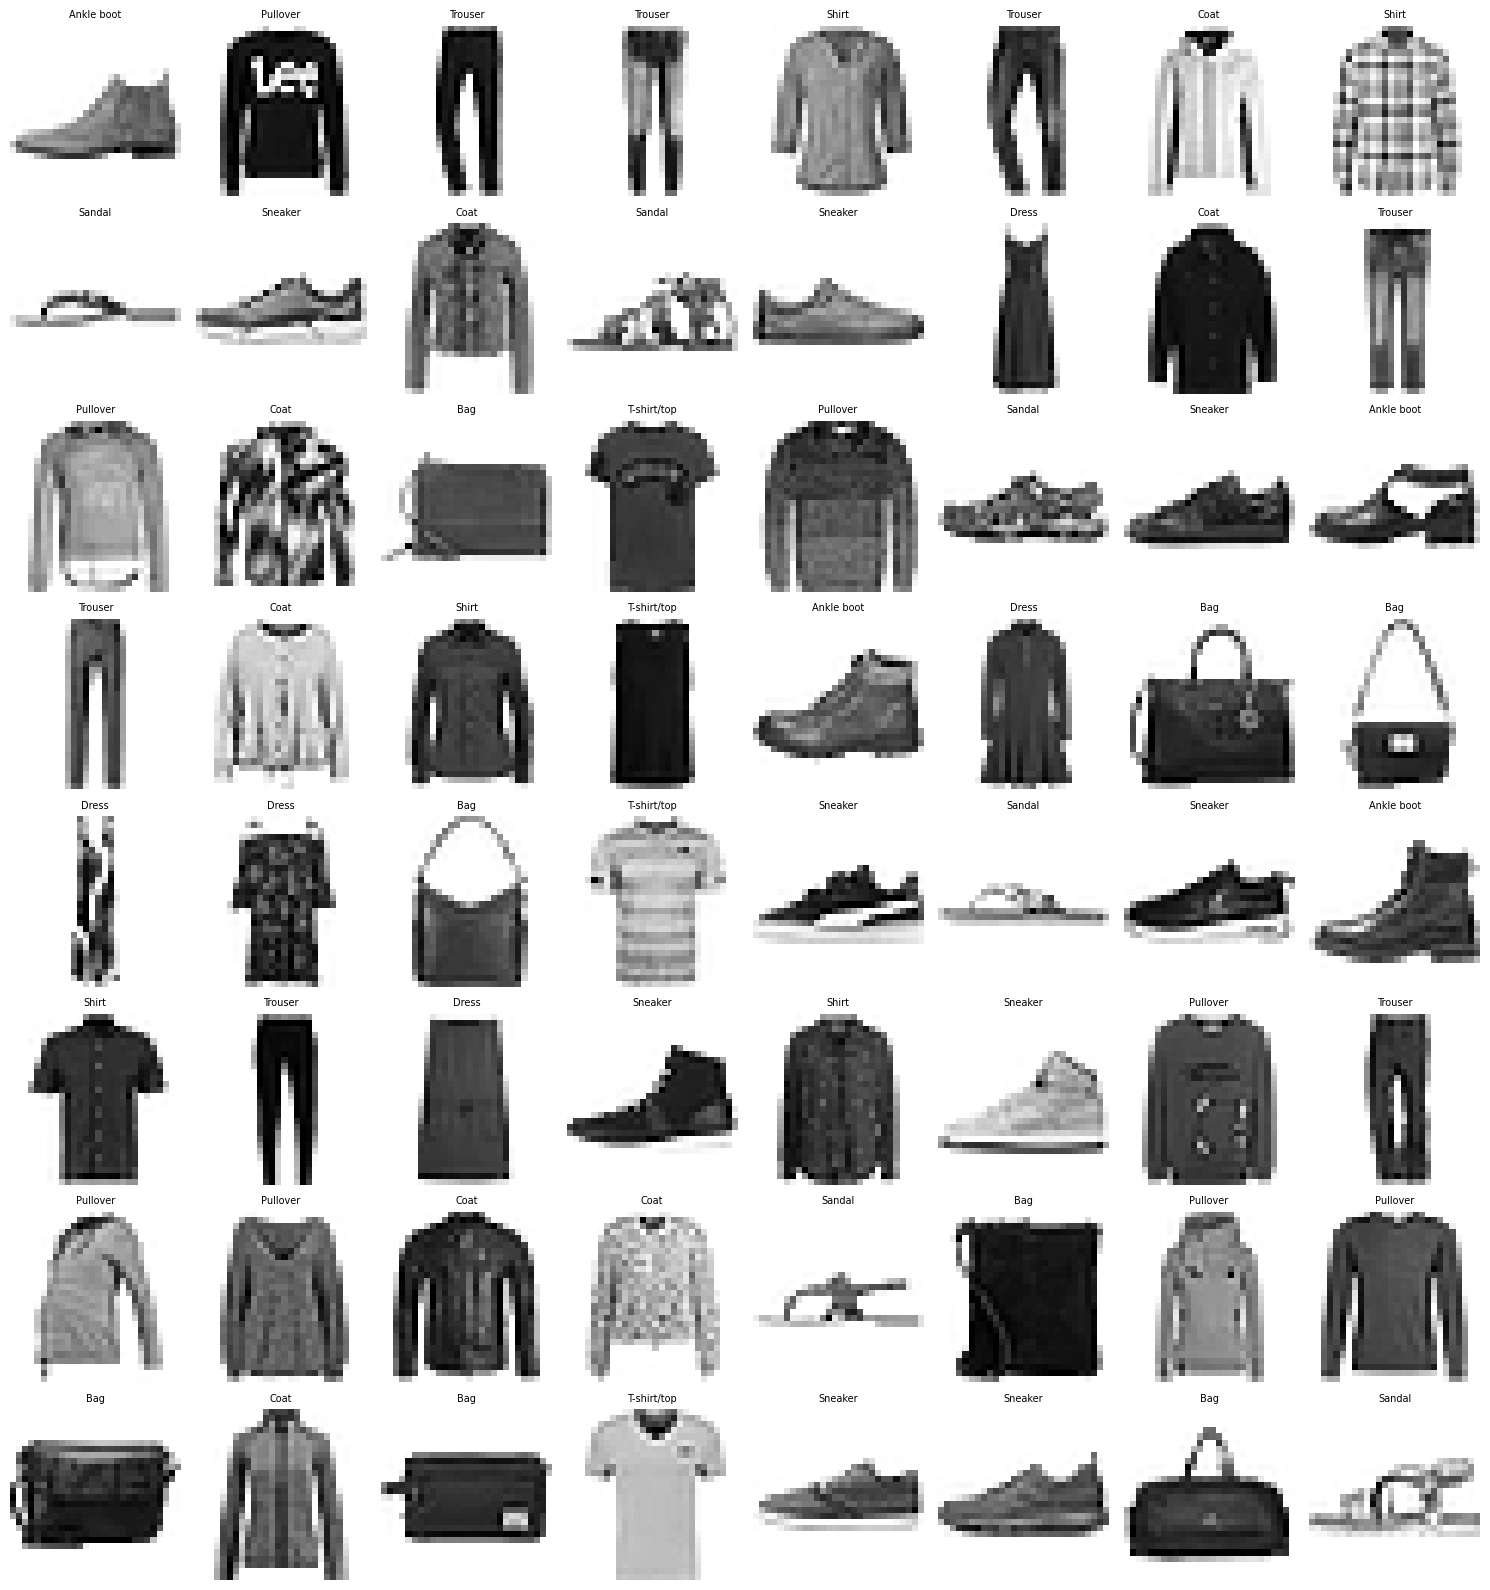

In [58]:
show_samples(test_loader,  class_names)

## Model Architecture



In [59]:
class CNNFashion(nn.Module):

    def __init__(self, num_classes=10):
        super(CNNFashion, self).__init__()

        dor1 = 0.10
        dor2 = 0.20
        dor3 = 0.30
        dor4 = 0.40

        # ── Set 1 ──
        self.conv1    = nn.Conv2d(in_channels=1, out_channels=32,
                                  kernel_size=3, padding='same')   # 32 x 28 x 28
        self.bn1      = nn.BatchNorm2d(32)
        self.relu1    = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)      # 32 x 14 x 14
        self.do1      = nn.Dropout(p=dor1)

        # ── Set 2 ──
        self.conv2    = nn.Conv2d(in_channels=32, out_channels=64,
                                  kernel_size=3, padding='same')   # 64 x 14 x 14
        self.bn2      = nn.BatchNorm2d(64)
        self.relu2    = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)      # 64 x  7 x  7
        self.do2      = nn.Dropout(p=dor2)

        # ── Set 3 ──
        self.conv3    = nn.Conv2d(in_channels=64, out_channels=128,
                                  kernel_size=3, padding='same')   # 128 x 7 x 7
        self.bn3      = nn.BatchNorm2d(128)
        self.relu3    = nn.ReLU()
        self.do3      = nn.Dropout(p=dor3)

        # ── Flatten ──
        self.flatten  = nn.Flatten()                               # 6272

        # ── Dense Head ──
        self.fc1      = nn.Linear(6272, 256)                       # 6272 → 256
        self.bn_fc1   = nn.BatchNorm1d(256)
        self.relu_fc1 = nn.ReLU()
        self.do4      = nn.Dropout(p=dor4)

        # ── Output ──
        self.fc2      = nn.Linear(256, num_classes)                # 256 → 10


        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Set 1: 1x28x28 → 32x28x28 → 32x14x14
        x = self.do1(self.maxpool1(self.relu1(self.bn1(self.conv1(x)))))

        # Set 2: 32x14x14 → 64x14x14 → 64x7x7
        x = self.do2(self.maxpool2(self.relu2(self.bn2(self.conv2(x)))))

        # Set 3: 64x7x7 → 128x7x7 (no MaxPool)
        x = self.do3(self.relu3(self.bn3(self.conv3(x))))

        # Flatten: 128x7x7 → 6272
        x = self.flatten(x)

        # Dense: 6272 → 256
        x = self.do4(self.relu_fc1(self.bn_fc1(self.fc1(x))))

        # Output: 256 → 10
        return self.fc2(x)


model = CNNFashion(num_classes=10).to(device)
print(model)

CNNFashion(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (do1): Dropout(p=0.1, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (do2): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (do3): Dropout(p=0.3, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=6272, out_features=256, bias=True)
  (bn_fc1): BatchNorm1d(256, eps=1e-0

In [60]:
# ── Loss ──
loss_fn = nn.CrossEntropyLoss()

# ── Optimizer: AdamW — L2 via weight_decay + gradient clipping ──
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=ALPHA,
    weight_decay=WEIGHT_DECAY   # L2 regularization
)

# ── LR Scheduler ──
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR
)

save_path = os.path.join(modelDir, subDir, f'{altName}.pth')
print('Setup complete.')

Setup complete.


## Train & Evaluate Functions

In [61]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc  = 0.0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs    = model(inputs)
        batch_loss = loss_fn(outputs, labels)
        batch_loss.backward()

        # Gradient clipping — removes loss spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        preds       = torch.argmax(outputs, dim=1)
        total_loss += batch_loss.item() * inputs.size(0)
        total_acc  += (preds == labels).sum().item()

    return total_loss / len(loader.dataset), total_acc / len(loader.dataset)


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0

    with torch.inference_mode():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs    = model(inputs)
            batch_loss = loss_fn(outputs, labels)

            preds       = torch.argmax(outputs, dim=1)
            total_loss += batch_loss.item() * inputs.size(0)
            total_acc  += (preds == labels).sum().item()

    return total_loss / len(loader.dataset), total_acc / len(loader.dataset)

## Training Loop

In [62]:
n_epoch      = []
train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []

minLoss  = float('inf')
counter  = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, loss_fn, device)

    scheduler.step(test_loss)

    n_epoch.append(epoch)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # ── Early stopping + save best model ──
    if test_loss < minLoss:
        minLoss = test_loss
        counter = 0
        torch.save({'epoch':                epoch + 1,
                    'model_state_dict':     model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss':                 test_loss}, save_path)
    else:
        counter += 1

    if counter > PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Loss: {train_loss:.4f}/{test_loss:.4f} | '
              f'Acc: {train_acc:.4f}/{test_acc:.4f} | '
              f'LR: {scheduler.get_last_lr()[0]:.6f} | '
              f'Counter: {counter}')

print(f'\nBest test loss: {minLoss:.4f}')

Epoch   0/60 | Loss: 0.7080/0.4585 | Acc: 0.7416/0.8313 | LR: 0.000500 | Counter: 0
Epoch  10/60 | Loss: 0.3418/0.2455 | Acc: 0.8760/0.9123 | LR: 0.000500 | Counter: 0
Epoch  20/60 | Loss: 0.2998/0.2252 | Acc: 0.8895/0.9180 | LR: 0.000500 | Counter: 0
Epoch  30/60 | Loss: 0.2782/0.2113 | Acc: 0.8990/0.9246 | LR: 0.000500 | Counter: 0
Epoch  40/60 | Loss: 0.2616/0.2121 | Acc: 0.9040/0.9249 | LR: 0.000500 | Counter: 4
Epoch  50/60 | Loss: 0.2396/0.1938 | Acc: 0.9137/0.9304 | LR: 0.000150 | Counter: 0

Best test loss: 0.1865


In [63]:
loss_df = pd.DataFrame({'epoch':     n_epoch,
                        'loss':      train_losses,
                        'test_loss': test_losses,
                        'acc':       train_accs,
                        'test_acc':  test_accs})

loss_df.head()

,epoch,loss,test_loss,acc,test_acc
0,0,0.707990,0.458506,0.741633,0.8313
1,1,0.503014,0.377336,0.812167,0.8607
2,2,0.460301,0.328582,0.830350,0.8780
3,3,0.428857,0.303222,0.842400,0.8905
4,4,0.405550,0.295739,0.850317,0.8928


In [64]:
def fn_plot_torch_hist(hist_df: pd.DataFrame):
    """
    Plots the training and validation loss and accuracy curves from a PyTorch training history DataFrame.

    Args:
        hist_df (pd.DataFrame): A pandas DataFrame with five columns:
                                - First column: epoch (x-axis values)
                                - Second & third columns: losses (train & validation)
                                - Fourth & fifth columns: accuracies (train & validation)

    Returns:
        None: Displays the matplotlib plots.
    """
    # Ensure the DataFrame has exactly five columns
    if hist_df.shape[1] < 5:
        raise ValueError("The DataFrame must have atleast five columns: epoch, train_loss, val_loss, train_acc, val_acc.")

    # Extract column names for better readability and maintainability
    #epoch loss	           test_loss	 acc	        test_acc
    x_col, train_loss_col, val_loss_col, train_acc_col, val_acc_col, *cols= hist_df.columns

    # Instantiate figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    facecolor = 'cyan'  # Text box background color
    fontsize = 12  # Font size for annotations
    props = dict(boxstyle='round', facecolor=facecolor, alpha=0.5)  # Text box properties

    # First subplot: Loss curves
    ax = axes[0]
    hist_df.plot(x=x_col, y=[train_loss_col, val_loss_col], ax=ax)

    # Annotation: Final losses
    final_losses_text = f"Loss:\nTrain: {hist_df[train_loss_col].iloc[-1]:.4f}\nVal: {hist_df[val_loss_col].iloc[-1]:.4f}"
    ax.text(0.3, 0.95, final_losses_text, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # Annotation: Minimum validation loss
    best_val_loss_idx = hist_df[val_loss_col].idxmin()
    best_val_loss_epoch = hist_df.loc[best_val_loss_idx, x_col]
    best_val_loss_value = hist_df.loc[best_val_loss_idx, val_loss_col]
    ax.annotate(f"Min: {best_val_loss_value:.4f}",
                xy=(best_val_loss_epoch, best_val_loss_value),
                xytext=(best_val_loss_epoch - 2, best_val_loss_value + 0.05),
                fontsize=fontsize, ha='right', va='bottom', bbox=props,
                arrowprops=dict(facecolor=facecolor, shrink=0.05))
    ax.axvline(x=best_val_loss_epoch, color='green', linestyle='-.', lw=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss Curves")
    ax.legend(loc='upper left')
    ax.grid(True)

    # Second subplot: Accuracy curves
    ax = axes[1]
    hist_df.plot(x=x_col, y=[train_acc_col, val_acc_col], ax=ax)

    # Annotation: Final accuracies
    final_acc_text = f"Accuracy:\nTrain: {hist_df[train_acc_col].iloc[-1]:.4f}\nVal: {hist_df[val_acc_col].iloc[-1]:.4f}"
    ax.text(0.3, 0.2, final_acc_text, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # Annotation: corresponding validation accuracy
    best_val_acc_epoch = hist_df.loc[best_val_loss_idx, x_col]
    best_val_acc_value = hist_df.loc[best_val_loss_idx, val_acc_col]
    ax.annotate(f"Max: {best_val_acc_value:.4f}",
                xy=(best_val_acc_epoch, best_val_acc_value),
                xytext=(best_val_acc_epoch - 2, best_val_acc_value - 0.05),
                fontsize=fontsize, ha='right', va='top', bbox=props,
                arrowprops=dict(facecolor=facecolor, shrink=0.05))
    ax.axvline(x=best_val_acc_epoch, color='green', linestyle='-.', lw=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy Curves")
    ax.legend(loc='lower left')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

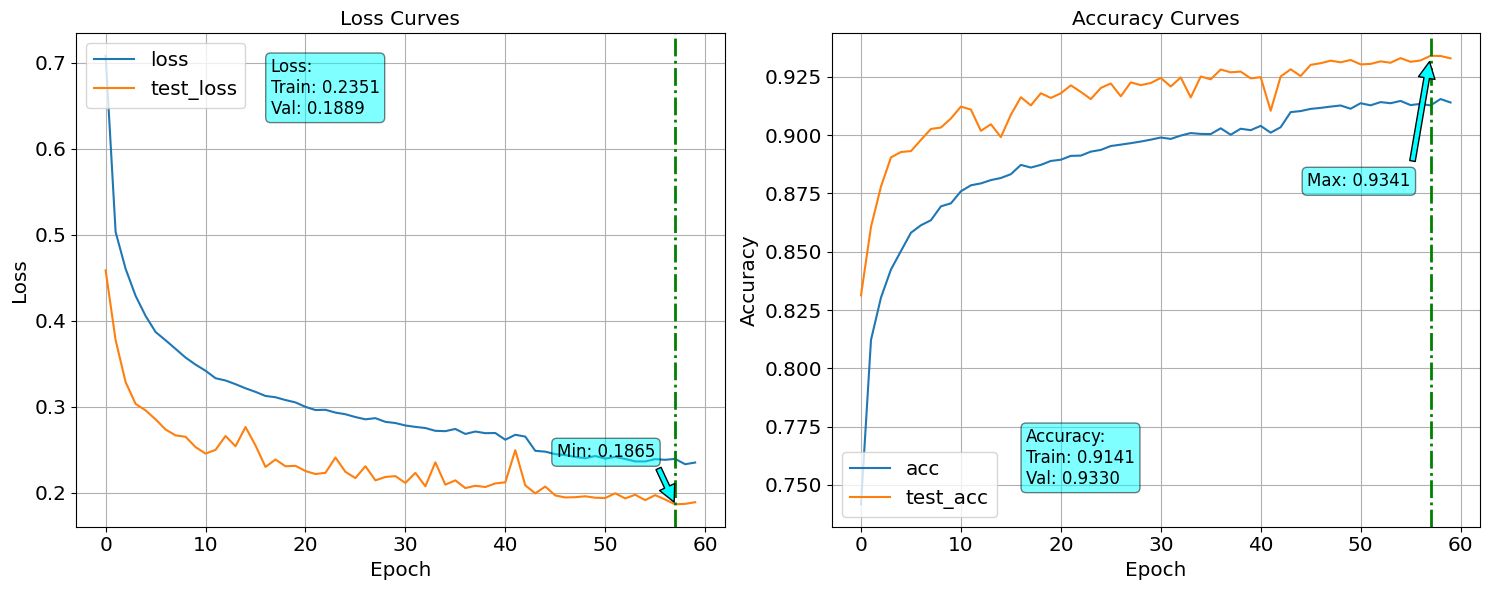

In [65]:
fn_plot_torch_hist(loss_df)

## Training Accuracy

In [66]:
y_train, y_pred = [], []

model.eval()

with torch.inference_mode():
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds   = torch.argmax(outputs, dim=1)
        y_train.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(f'Train Accuracy: {accuracy_score(y_train, y_pred):.5f}\n')
print(classification_report(y_train, y_pred, target_names=list(class_names.values())))

Train Accuracy: 0.93480

              precision    recall  f1-score   support

 T-shirt/top       0.91      0.89      0.90      6000
     Trouser       0.99      0.99      0.99      6000
    Pullover       0.90      0.90      0.90      6000
       Dress       0.93      0.95      0.94      6000
        Coat       0.88      0.90      0.89      6000
      Sandal       0.99      0.98      0.99      6000
       Shirt       0.82      0.80      0.81      6000
     Sneaker       0.96      0.98      0.97      6000
         Bag       0.99      0.99      0.99      6000
  Ankle boot       0.98      0.97      0.97      6000

    accuracy                           0.93     60000
   macro avg       0.93      0.93      0.93     60000
weighted avg       0.93      0.93      0.93     60000



In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth
        y_pred : Predictions
        labels : labels in a dictonary
                  {0: 'Goal Keeper',
                  1: 'Defender',
                  2: 'Mid-Fielder',
                  3: 'Forward'}

    '''

    cm  = confusion_matrix(y_true, y_pred)

    if isinstance(labels, dict):
        display_labels = labels.values()
    else:
        display_labels = labels

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=display_labels)

    fig, ax = plt.subplots(figsize = (5,5))

    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)

    # Disable the grid
    ax.grid(False)

    title_str = f"F1 Score : {f1_score(y_true, y_pred, average='weighted'):0.5f}"
    ax.set_title(title_str)

    plt.show()

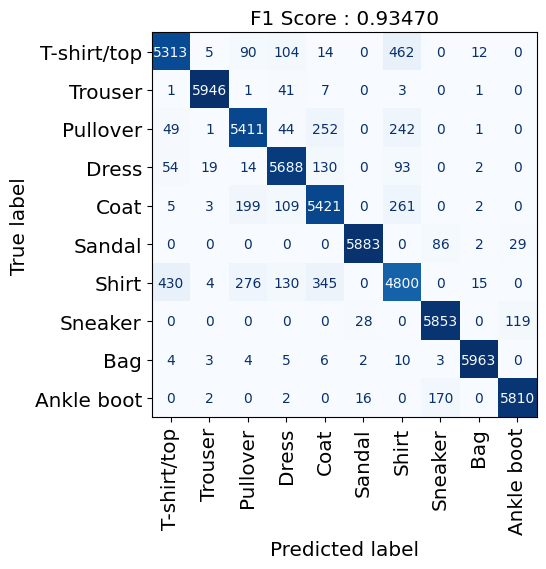

In [68]:
fn_plot_confusion_matrix(y_train, y_pred, class_names)

## Testing Accuracy

In [69]:
y_test, y_pred = [], []

model.eval()

with torch.inference_mode():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds   = torch.argmax(outputs, dim=1)
        y_test.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.5f}\n')
print(classification_report(y_test, y_pred, target_names=list(class_names.values())))

Test Accuracy: 0.93300

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.87      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.90      0.90      0.90      1000
       Dress       0.95      0.93      0.94      1000
        Coat       0.88      0.92      0.90      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.80      0.79      0.80      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



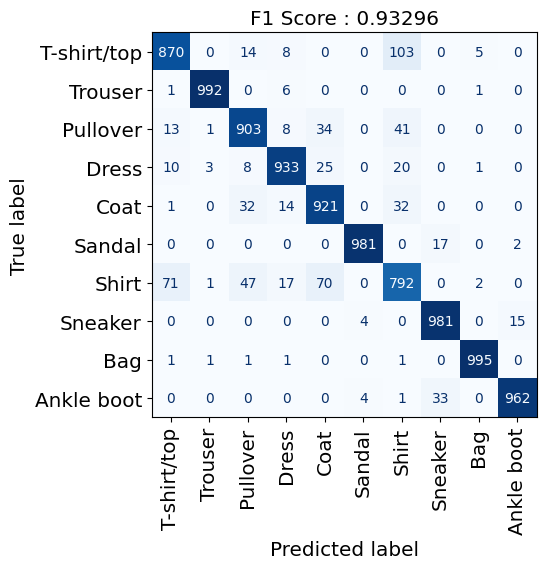

In [70]:
fn_plot_confusion_matrix(y_test, y_pred, class_names)

## Load Best Saved Model

Loaded best model — epoch 58, loss 0.1865

Best Model Test Accuracy: 0.93410

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.90      0.89      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.90      0.91      0.90      1000
       Dress       0.93      0.95      0.94      1000
        Coat       0.89      0.91      0.90      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.82      0.77      0.79      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



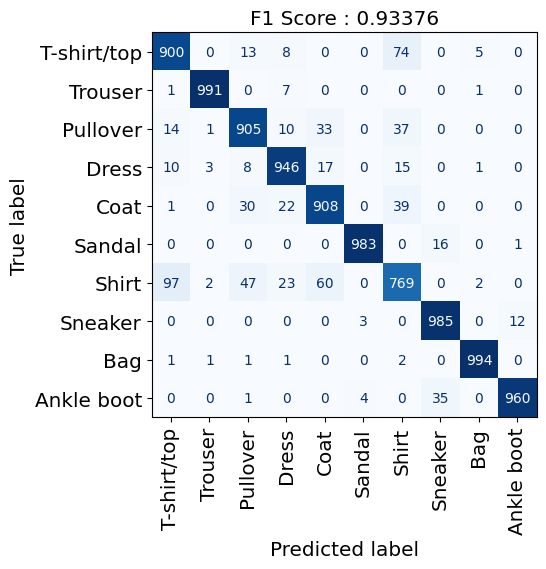

In [71]:
best_model = CNNFashion(num_classes=10).to(device)
checkpoint = torch.load(save_path)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()
print(f"Loaded best model — epoch {checkpoint['epoch']}, loss {checkpoint['loss']:.4f}")

y_best, y_pred_best = [], []

with torch.inference_mode():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        preds = torch.argmax(best_model(inputs), dim=1)
        y_best.extend(labels.cpu().numpy())
        y_pred_best.extend(preds.cpu().numpy())

print(f'\nBest Model Test Accuracy: {accuracy_score(y_best, y_pred_best):.5f}\n')
print(classification_report(y_best, y_pred_best, target_names=list(class_names.values())))
fn_plot_confusion_matrix(y_best, y_pred_best, class_names)